# Population Exposure to Rising Temperatures — Data Preprocessing

This notebook builds one model-ready dataset from two raw sources:

1. **Berkeley Earth** country-level land temperatures (`GlobalLandTemperaturesByCountry.csv`)
2. **World Population Dataset** (`world_population.csv`)

Every non-obvious decision below is explained *before* the code that makes it, so the reasoning
is visible without having to reverse-engineer it from the pandas calls. Plotting helpers are
defined once, early, and reused throughout — and can be reused again later in the project
(EDA, modelling, report figures) without rewriting them.

In [112]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 50)

# Works whether this notebook sits in the project root or a notebooks/ subfolder.
PROJECT_ROOT = next(
    p for p in (Path.cwd(), Path.cwd().parent) if (p / "data" / "raw").exists()
)
RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUT_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/macrosh/Documents/Masters/3rd Sem/Machine Learning/Assessment_3


## 0. Reusable visualization helpers

Defined once, up front. Any teammate can call these again at any later point in the project —
during modelling, during report-writing, to double check a claim — instead of writing new
plotting code from scratch each time.

In [113]:
def quick_summary(df, name):
    """Shape, preview and missingness — our standard first look at any dataframe."""
    print(f"--- {name} ---")
    print("shape:", df.shape)
    display(df.head(3))
    missing = df.isna().mean().sort_values(ascending=False)
    missing = missing[missing > 0]
    if len(missing):
        print("columns with missing values (%):")
        display((missing * 100).round(2))


def plot_missingness(df, title, ax=None):
    pct = df.isna().mean().sort_values(ascending=False) * 100
    pct = pct[pct > 0]
    ax = ax or plt.gca()
    if pct.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center")
    else:
        pct.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("% missing")
    return ax


def plot_country_series(df, country_col, country_value, x, y, title=None, ax=None, fit_line=False):
    """Plot one country's series over time. Reused for temperature, population and density checks."""
    subset = df[df[country_col] == country_value].sort_values(x)
    ax = ax or plt.gca()
    ax.plot(subset[x], subset[y], marker="o")
    if fit_line and len(subset) > 1:
        coeffs = np.polyfit(subset[x], subset[y], 1)
        ax.plot(subset[x], np.polyval(coeffs, subset[x]), linestyle="--", alpha=0.7,
                label=f"trend: {coeffs[0]:+.3f}/yr")
        ax.legend()
    ax.set_title(title or f"{country_value}: {y} over {x}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    return ax


def plot_hist(series, title, xlabel, bins=30, ax=None):
    ax = ax or plt.gca()
    series.dropna().plot(kind="hist", bins=bins, ax=ax, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    return ax


def plot_class_counts(train_series, test_series, class_order, title, ax=None):
    counts = pd.DataFrame({
        "Training": train_series.value_counts().reindex(class_order),
        "Testing": test_series.value_counts().reindex(class_order),
    })
    ax = counts.plot(kind="bar", rot=0, ax=ax)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    return ax

## 1. Load and inspect the raw data

Before transforming anything, we look at both datasets as they arrived — size, columns, and
where values are missing. This is what tells us, in the next step, which dataset should anchor
the merge, rather than that being an arbitrary choice.

--- Climate (Berkeley Earth) ---
shape: (577462, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland


columns with missing values (%):


AverageTemperature               5.65
AverageTemperatureUncertainty    5.53
dtype: float64

--- Population (World Population Dataset) ---
shape: (234, 17)


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56


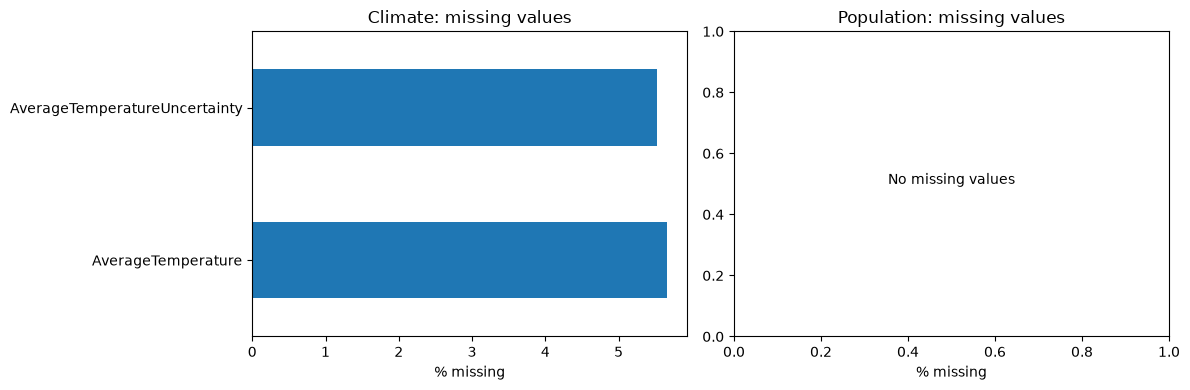


Unique 'Country' labels in climate data: 243
Unique countries/territories in population data: 234


In [114]:
climate = pd.read_csv(RAW_DIR / "GlobalLandTemperaturesByCountry.csv")
population = pd.read_csv(RAW_DIR / "world_population.csv")

quick_summary(climate, "Climate (Berkeley Earth)")
quick_summary(population, "Population (World Population Dataset)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_missingness(climate, "Climate: missing values", ax=axes[0])
plot_missingness(population, "Population: missing values", ax=axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / "01_raw_missingness.png", dpi=200)
plt.show()

print("\nUnique 'Country' labels in climate data:", climate["Country"].nunique())
print("Unique countries/territories in population data:", population["Country/Territory"].nunique())

## 2. Deciding which dataset anchors the merge

This shouldn't be arbitrary, and the raw data gives a clear answer:

- The **population** dataset has one row per officially recognised country or territory, each
  with a stable ISO `CCA3` code — about 234 rows. This is a clean, canonical country list.
- The **climate** dataset's `Country` column has *more* distinct labels than there are real
  countries, because Berkeley Earth includes continents and some aggregated/former political
  entities alongside real countries, and has no country-code column at all.

So we treat **population as the canonical list** and check, for each of its countries, whether
we have matching climate data — not the reverse. If we anchored on climate instead, continents
and non-country entities would end up sitting in our "master" table, and we'd have no direct way
to see which *real* countries are missing climate coverage.

In [115]:
climate_countries = climate["Country"].unique()
population_countries = population["Country/Territory"].unique()
print("\nCountries in climate data but not in population data:", list(set(climate_countries) -  set(population_countries)))
print("Countries in population data but not in climate data:", list(set(population_countries) -  set(climate_countries)))


Countries in climate data but not in population data: ['United Kingdom (Europe)', 'Isle Of Man', 'Timor Leste', 'Guinea Bissau', 'Swaziland', 'Congo (Democratic Republic Of The)', 'Denmark (Europe)', 'Sao Tome And Principe', 'Saint Pierre And Miquelon', 'Oceania', 'Turks And Caicas Islands', 'Antarctica', 'Macedonia', 'French Southern And Antarctic Lands', 'Gaza Strip', 'Africa', 'Saint Barthélemy', 'Federated States Of Micronesia', 'Saint Kitts And Nevis', 'Trinidad And Tobago', 'Congo', 'Saint Vincent And The Grenadines', 'Asia', 'North America', 'Virgin Islands', 'Palestina', 'Burma', 'Kingman Reef', 'Antigua And Barbuda', 'South Georgia And The South Sandwich Isla', 'Europe', 'Christmas Island', 'Svalbard And Jan Mayen', 'Netherlands (Europe)', 'Bonaire, Saint Eustatius And Saba', 'Curaçao', 'Baker Island', 'South America', "Côte D'Ivoire", 'France (Europe)', 'Falkland Islands (Islas Malvinas)', 'Heard Island And Mcdonald Islands', 'Bosnia And Herzegovina', 'Palmyra Atoll', 'Åland

In [116]:
# A few climate "Country" labels that are not real countries
non_country_examples = ["Africa", "Asia", "Europe", "North America", "South America",
                         "Antarctica", "Oceania"]
found = climate["Country"].drop_duplicates()
print("Non-country entities present in the climate data:",
      found[found.isin(non_country_examples)].tolist())

Non-country entities present in the climate data: ['Africa', 'Antarctica', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']


Some countries are named with (Europe) in the suffix. We are trying to look at the data manually if they vary.

In [117]:
print(climate[climate["Country"]=="Denmark (Europe)"].dropna().head())
print(climate[climate["Country"]=="Denmark"].dropna().head())
climate.loc[climate["Country"].str.contains("europe", case=False, na=False), "Country"].unique()

                dt  AverageTemperature  AverageTemperatureUncertainty  \
139254  1743-11-01               6.507                          1.767   
139259  1744-04-01               6.026                          3.472   
139260  1744-05-01              10.413                          1.359   
139261  1744-06-01              13.630                          1.430   
139262  1744-07-01              15.755                          1.477   

                 Country  
139254  Denmark (Europe)  
139259  Denmark (Europe)  
139260  Denmark (Europe)  
139261  Denmark (Europe)  
139262  Denmark (Europe)  
                dt  AverageTemperature  AverageTemperatureUncertainty  Country
142493  1823-01-01             -29.446                          3.646  Denmark
142494  1823-02-01             -31.746                          3.438  Denmark
142495  1823-03-01             -28.439                          2.757  Denmark
142496  1823-04-01             -21.488                          3.379  Denmark
1424

<StringArray>
[       'Denmark (Europe)',                  'Europe',
         'France (Europe)',    'Netherlands (Europe)',
 'United Kingdom (Europe)']
Length: 5, dtype: str

It is interesting that Denmark (Europe) has average temperature > 6 while Denmark has average temperature <-12.

## 3. Building the country crosswalk

Names are normalised (case, accents, punctuation) so trivial formatting differences don't block
a match, then a short, manually reviewed alias list covers cases where the two datasets
genuinely use different names for the same country (e.g. Burma vs Myanmar).

In [118]:
def normalize_name(name):
    name = unicodedata.normalize("NFKD", str(name))
    name = "".join(c for c in name if not unicodedata.combining(c))
    name = name.casefold().replace("&", " and ")
    return re.sub(r"[^a-z0-9]+", " ", name).strip() # -> "cote d ivoire"


# Manually reviewed: same country, genuinely different name across the two datasets.
COUNTRY_ALIASES = {
    "burma": "myanmar",
    "congo": "republic of the congo",
    "congo democratic republic of the": "dr congo",
    "cote d ivoire": "ivory coast", # Côte D'Ivoire is normalized into cote d ivoire which is ivory coast
    "macedonia": "north macedonia",
    "swaziland": "eswatini",
    "falkland islands islas malvinas": "falkland islands",
    "federated states of micronesia": "micronesia",
    "turks and caicas islands": "turks and caicos islands",
    "virgin islands": "united states virgin islands",
    "palestina": "palestine",
    "denmark europe": "denmark",
    "france europe": "france",
    "netherlands europe": "netherlands",
    "united kingdom europe": "united kingdom",
}

### Regarding climate countries with (Europe) as suffix

Four countries appear **twice** in the climate data: once as a plain national aggregate, and
once with an `(Europe)` suffix.

| Country | Aggregate (plain) | `(Europe)` variant |
|---|---|---|
| Denmark | **−18.1 °C** | 7.8 °C |
| France | 12.8 °C | 10.4 °C |
| Netherlands | 9.5 °C | 9.1 °C |
| United Kingdom | 8.5 °C | 8.7 °C |

Plain "Denmark" averages **−18 °C** because Berkeley Earth's aggregate blends in Greenland's
arctic climate. But the population dataset's "Denmark" figure is the mainland population only
(around 5.9 million — Greenland and the Faroe Islands aren't counted as part of it here). If we
matched the plain aggregate by name — which is exactly what a naive exact-string match would
do, since "Denmark" matches "Denmark" perfectly — every Danish warming-trend feature would
silently be describing the wrong climate. The `(Europe)` variant is the mainland-only series and
is the correct match. The same reasoning applies to France, the Netherlands and the UK.

So the plain aggregates are excluded outright, and the aliases above redirect the `(Europe)`
variant onto the real country name instead.

Because population is the anchor, the merge is `population.merge(climate_names, how="left")`.
Every row in the result is a real country, and any row with no climate match is a country we
genuinely have no climate coverage for — visible immediately, not hidden inside an inner join.

Population countries matched to climate data: 221 / 234

Population countries with NO climate coverage:
['Bermuda', 'Brunei', 'Cook Islands', 'Gibraltar', 'Maldives', 'Marshall Islands', 'Nauru', 'South Sudan', 'Tokelau', 'Tuvalu', 'Vanuatu', 'Vatican City', 'Wallis and Futuna']

Climate labels never used:
['Africa', 'Antarctica', 'Asia', 'Baker Island', 'Bonaire, Saint Eustatius And Saba', 'Christmas Island', 'Europe', 'French Southern And Antarctic Lands', 'Gaza Strip', 'Heard Island And Mcdonald Islands', 'Kingman Reef', 'North America', 'Oceania', 'Palmyra Atoll', 'South America', 'South Georgia And The South Sandwich Isla', 'Svalbard And Jan Mayen', 'Åland']


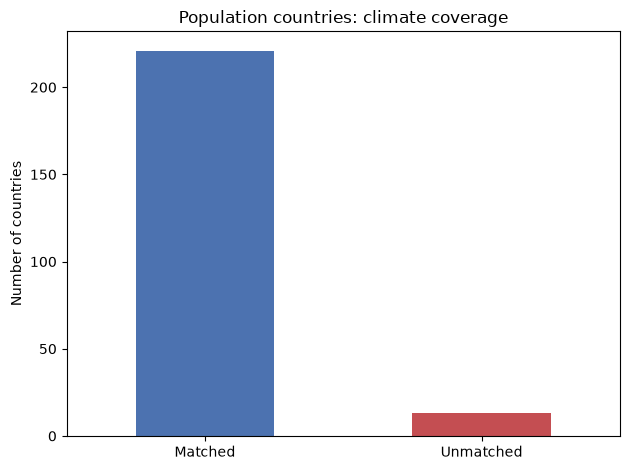

In [119]:
# These are the countries with suffix (Europe)
EXCLUDED_CLIMATE_LABELS = {"Denmark", "France", "Netherlands", "United Kingdom"}

population_names = population[["CCA3", "Country/Territory"]].drop_duplicates().copy()
population_names["join_key"] = population_names["Country/Territory"].map(normalize_name)
assert not population_names["join_key"].duplicated().any(), \
    "Population names collapse to a shared key."

climate_names = climate[["Country"]].drop_duplicates().copy()
climate_names = climate_names[~climate_names["Country"].isin(EXCLUDED_CLIMATE_LABELS)].copy()
climate_names["join_key"] = climate_names["Country"].map(normalize_name).replace(COUNTRY_ALIASES)
assert not climate_names["join_key"].duplicated().any(), \
    "Two climate country labels collapse to the same key."

crosswalk = population_names.merge(climate_names, on="join_key", how="left", indicator=True)
matched = crosswalk[crosswalk["_merge"] == "both"].drop(columns="_merge")
unmatched_population = crosswalk.loc[crosswalk["_merge"] == "left_only", "Country/Territory"]
unused_climate_labels = sorted(set(climate_names["Country"]) - set(matched["Country"]))

print(f"Population countries matched to climate data: {len(matched)} / {len(population_names)}")
print("\nPopulation countries with NO climate coverage:")
print(unmatched_population.tolist())
print("\nClimate labels never used:")
print(unused_climate_labels)

pd.Series({"Matched": len(matched), "Unmatched": len(unmatched_population)}).plot(
    kind="bar", rot=0, color=["#4C72B0", "#C44E52"], title="Population countries: climate coverage"
)
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_country_matching.png", dpi=200)
plt.show()

## 4. Annual climate aggregation

Monthly temperatures are averaged into annual means, but only from years with all 12 months
present — a year built from, say, four winter months would be biased, not just noisier.

**The trade-off is made visible, not hidden:** requiring complete years drops some
country-years, and that loss is probably not random — countries with weaker historical
weather-station networks likely lose more. The chart below shows exactly which countries are
affected, so this is something we can point to directly if we discuss it as a limitation.

Complete country-years: 40552
Incomplete country-years dropped: 3587 (8.1%)


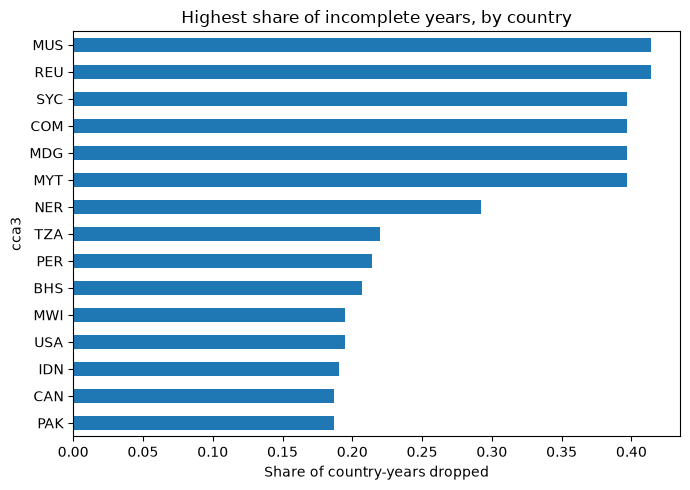

In [120]:
climate_matched = (
    climate.merge(matched[["Country", "CCA3"]], on="Country", how="inner")
    .rename(columns={"CCA3": "cca3"})
)
climate_matched["year"] = pd.to_datetime(climate_matched["dt"]).dt.year

annual = (
    climate_matched.groupby(["cca3", "year"])
    .agg(annual_mean_temp_c=("AverageTemperature", "mean"),
         valid_months=("AverageTemperature", "count"),
         annual_mean_uncertainty_c=("AverageTemperatureUncertainty", "mean"))
    .reset_index()
)

complete = annual[annual["valid_months"] == 12].copy()
incomplete = annual[annual["valid_months"] < 12].copy()

print(f"Complete country-years: {len(complete)}")
print(f"Incomplete country-years dropped: {len(incomplete)} ({len(incomplete) / len(annual):.1%})")

drop_rate_by_country = (
    incomplete.groupby("cca3").size().div(annual.groupby("cca3").size())
    .dropna().sort_values(ascending=False)
)
drop_rate_by_country.head(15).plot(
    kind="barh", figsize=(7, 5), title="Highest share of incomplete years, by country"
)
plt.xlabel("Share of country-years dropped")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_incomplete_years.png", dpi=200)
plt.show()

annual = complete

## 5. Turning years into decades

For each complete decade we fit a straight-line trend through the annual temperatures.
Its slope becomes `warming_c_per_decade`; the spread of points around that line
(`detrended_volatility_c`) captures year-to-year variability *separately* from the underlying
trend.

We stop at the 2000s decade (1960–2009) for a specific reason: Berkeley Earth's data ends in
2013, so the 2010s can never be a *complete* decade here — including it would mean comparing a
full 10-year trend for older decades against a partial ~4-year one for the most recent decade,
which isn't a fair like-for-like comparison. Five properly complete decades beat six
inconsistent ones.

Country-decade records: 1105


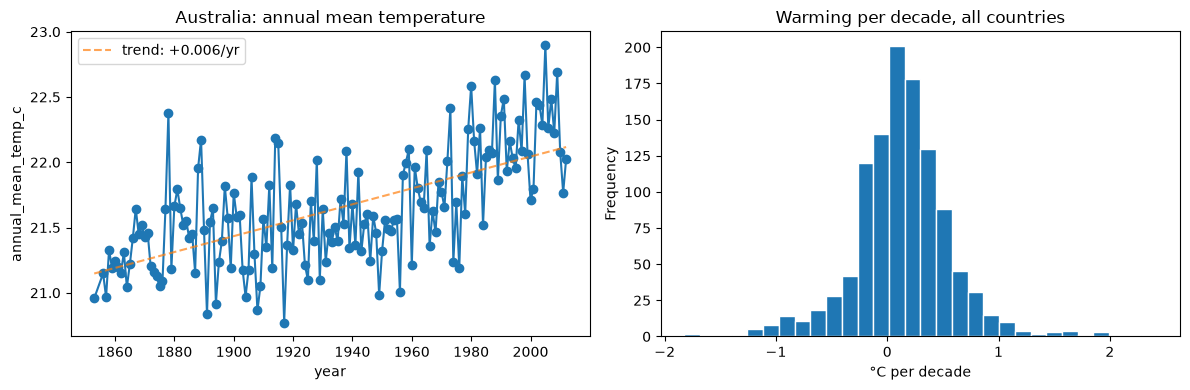

In [121]:
records = []
for cca3, group in annual.groupby("cca3"):
    group = group.set_index("year")
    for start in range(1960, 2001, 10):
        years = np.arange(start, start + 10)
        if not set(years).issubset(group.index):
            continue
        decade = group.loc[years]
        x = years - years.mean()
        y = decade["annual_mean_temp_c"].to_numpy()
        slope = np.dot(x, y - y.mean()) / np.dot(x, x)
        residuals = y - (y.mean() + slope * x)
        records.append({
            "cca3": cca3,
            "decade_start": start,
            "mean_temp_c": y.mean(),
            "warming_c_per_decade": slope * 10,
            "detrended_volatility_c": residuals.std(ddof=1),
            "mean_uncertainty_c": decade["annual_mean_uncertainty_c"].mean(),
        })

decades = pd.DataFrame(records)
print(f"Country-decade records: {len(decades)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_country_series(annual, "cca3", "AUS", "year", "annual_mean_temp_c",
                     title="Australia: annual mean temperature", ax=axes[0], fit_line=True)
plot_hist(decades["warming_c_per_decade"], "Warming per decade, all countries", "°C per decade", ax=axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / "04_decadal_climate.png", dpi=200)
plt.show()

## 6. Turning population snapshots into a time series

The population dataset stores each year as its own column (`1970 Population`,
`1980 Population`, ...) — fine for a spreadsheet, not for merging with a year-indexed climate
table — so it's reshaped ("melted") into one row per country per year.

Density is computed ourselves as `population / area` for **every** historical year, rather than
using the dataset's built-in `Density (per km²)` column — that column only reflects the most
recent year (2022), and the project needs density at each historical reference year (1970,
1980, 1990, 2000), not just the present.

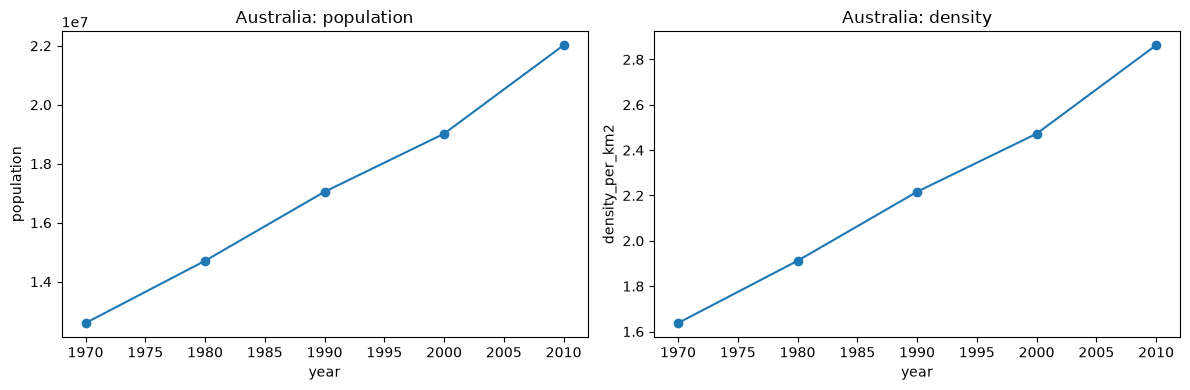

In [122]:
POP_YEARS = [1970, 1980, 1990, 2000, 2010]

panel = population.melt(
    id_vars=["CCA3", "Country/Territory", "Continent", "Area (km²)"],
    value_vars=[f"{y} Population" for y in POP_YEARS],
    var_name="year", value_name="population",
).rename(columns={
    "CCA3": "cca3", "Country/Territory": "country",
    "Continent": "continent", "Area (km²)": "area_km2",
})

panel["year"] = panel["year"].str.extract(r"(\d{4})").astype(int)
panel = panel.sort_values(["cca3", "year"])
panel["density_per_km2"] = panel["population"] / panel["area_km2"]

# Growth vs the previous available snapshot. No 1960 figure exists in this dataset,
# so 1970\'s "prior decade growth" is genuinely unknown and stays NaN — not guessed.
panel["growth_prior_decade_pct"] = panel.groupby("cca3")["population"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_country_series(panel, "cca3", "AUS", "year", "population", title="Australia: population", ax=axes[0])
plot_country_series(panel, "cca3", "AUS", "year", "density_per_km2", title="Australia: density", ax=axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / "05_population_panel.png", dpi=200)
plt.show()

## 7. Aligning predictors and outcomes in time

This is the step that stops the model from cheating. For a chosen reference year `t`
(1970, 1980, 1990 or 2000):

- **Predictors** use only information available *by* year `t`: the *prior* decade's climate
  trend (`t-10` to `t-1`) and the population figures *at* `t`.
- **Outcomes** (used only to build the label, never fed to a model) come from *after* `t`: the
  *following* decade's warming (`t` to `t+9`) and the population/density at `t+10`.

Letting any post-`t` information leak into the predictor columns would tell the model the
answer before asking it the question — a common and easy-to-miss mistake in time-based
ML projects.

Country-period observations: 884


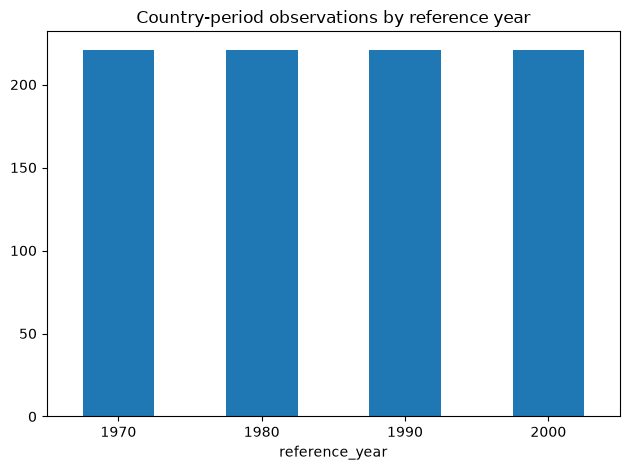

In [123]:
REFERENCE_YEARS = [1970, 1980, 1990, 2000]

ref_population = panel[panel["year"].isin(REFERENCE_YEARS)].rename(columns={
    "year": "reference_year",
    "population": "population_at_reference",
    "density_per_km2": "density_at_reference",
    "growth_prior_decade_pct": "population_growth_prior_decade_pct",
})
ref_population["prior_decade_start"] = ref_population["reference_year"] - 10

prior_climate = decades.rename(columns={
    "decade_start": "prior_decade_start",
    "mean_temp_c": "prior_decade_mean_temp_c",
    "warming_c_per_decade": "prior_decade_warming_c_per_decade",
    "detrended_volatility_c": "prior_decade_volatility_c",
    "mean_uncertainty_c": "prior_decade_uncertainty_c",
})
periods = ref_population.merge(prior_climate, on=["cca3", "prior_decade_start"], how="inner")

future_climate = decades.rename(columns={
    "decade_start": "reference_year",
    "warming_c_per_decade": "future_warming_c_per_decade",
})
periods = periods.merge(
    future_climate[["cca3", "reference_year", "future_warming_c_per_decade"]],
    on=["cca3", "reference_year"], how="inner",
)

periods["outcome_year"] = periods["reference_year"] + 10
future_population = panel.rename(columns={
    "year": "outcome_year",
    "density_per_km2": "future_density_per_km2",
    "population": "outcome_population",
})
periods = periods.merge(
    future_population[["cca3", "outcome_year", "future_density_per_km2", "outcome_population"]],
    on=["cca3", "outcome_year"], how="inner",
)

print(f"Country-period observations: {len(periods)}")
periods.groupby("reference_year").size().plot(
    kind="bar", rot=0, title="Country-period observations by reference year"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_country_periods.png", dpi=200)
plt.show()

## 8. Constructing the exposure label

A country should count as **High** exposure only if it's high on *both* future warming and
future population density — a hot, empty desert and a cool, crowded city are not the same kind
of risk. Each component is ranked as a percentile **against the training years only**
(1970/80/90), then combined with a **geometric mean**:
`sqrt(warming_percentile × density_percentile)`. Unlike an arithmetic mean, a geometric mean
drags the combined score down hard if either component is low — which is what we want, since
being extreme on only one dimension shouldn't be enough to earn a High label.

Density is log-transformed (`log1p`) before ranking because population density is heavily
right-skewed — a handful of very dense countries would otherwise dominate the percentile
ranking.

Class boundaries (the cut-points between Low/Medium/High) are computed **only from the training
years** and then applied unchanged to the test year (2000) — the same way this would have to
work in practice, since next-decade information is never available at the point of prediction.

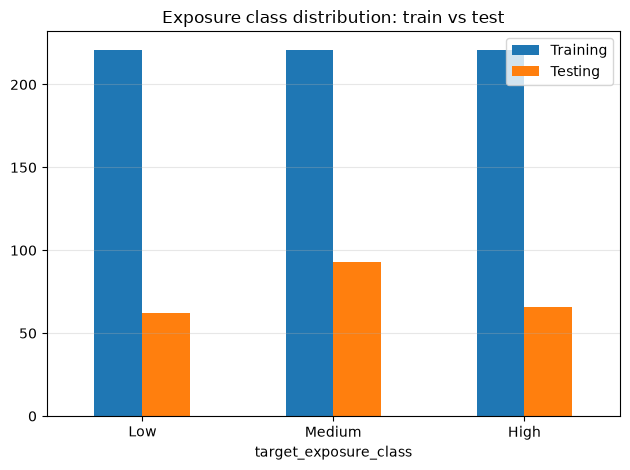

In [126]:
TRAIN_YEARS = [1970, 1980, 1990]
TEST_YEAR = 2000
CLASS_ORDER = ["Low", "Medium", "High"]

train = periods[periods["reference_year"].isin(TRAIN_YEARS)].copy()
test = periods[periods["reference_year"] == TEST_YEAR].copy()


def percentile_rank(values, reference_sorted):
    return np.searchsorted(reference_sorted, values, side="right") / len(reference_sorted)


warming_ref = np.sort(train["future_warming_c_per_decade"])
density_ref = np.sort(np.log1p(train["future_density_per_km2"]))

for df in (train, test):
    df["warming_pct"] = percentile_rank(df["future_warming_c_per_decade"], warming_ref)
    df["density_pct"] = percentile_rank(np.log1p(df["future_density_per_km2"]), density_ref)
    df["exposure_index"] = np.sqrt(df["warming_pct"] * df["density_pct"])

cutoffs = np.quantile(train["exposure_index"], [1 / 3, 2 / 3])
for df in (train, test):
    df["target_exposure_class"] = pd.Categorical(
        np.select(
            [df["exposure_index"] < cutoffs[0], df["exposure_index"] < cutoffs[1]],
            ["Low", "Medium"], default="High",
        ),
        categories=CLASS_ORDER, ordered=True,
    )

plot_class_counts(train["target_exposure_class"], test["target_exposure_class"], CLASS_ORDER,
                   "Exposure class distribution: train vs test")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_label_distribution.png", dpi=200)
plt.show()

## 9. Assembling the model-ready files

Only features genuinely available *by* the reference year go into the model files. The outcome
variables used to build the label above are dropped and explicitly checked for, so a leaked
feature can never slip back in silently after a later edit.

In [128]:
NUMERIC_PREDICTORS = [
    "population_at_reference", "density_at_reference", "population_growth_prior_decade_pct",
    "prior_decade_mean_temp_c", "prior_decade_warming_c_per_decade", "prior_decade_volatility_c",
    "prior_decade_uncertainty_c", "area_km2",
]
CATEGORICAL_PREDICTORS = ["continent"]
MODEL_COLUMNS = (
    ["country", "cca3", "reference_year"] + NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS
    + ["target_exposure_class"]
)

FORBIDDEN = {"future_warming_c_per_decade", "future_density_per_km2", "outcome_population",
             "exposure_index", "warming_pct", "density_pct"}

train_model = train[MODEL_COLUMNS]
test_model = test[MODEL_COLUMNS]

train_model.to_csv(OUT_DIR / "ml_train.csv", index=False)
test_model.to_csv(OUT_DIR / "ml_test.csv", index=False)
crosswalk.to_csv(OUT_DIR / "country_matching_audit.csv", index=False)
decades.to_csv(OUT_DIR / "decadal_climate_features.csv", index=False)
panel.to_csv(OUT_DIR / "historical_population_panel.csv", index=False)

print("Training rows:", len(train_model), "| Testing rows:", len(test_model))
display(train_model.head())

Training rows: 663 | Testing rows: 221


,country,cca3,reference_year,population_at_reference,density_at_reference,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_volatility_c,prior_decade_uncertainty_c,area_km2,continent,target_exposure_class
0,Aruba,ABW,1970,59106,328.366667,NaN,28.199408,0.107460,0.189841,0.358767,180,North America,High
1,Aruba,ABW,1980,62267,345.927778,5.348019,28.167542,0.197955,0.287829,0.327217,180,North America,Low
2,Aruba,ABW,1990,65712,365.066667,5.532626,28.342575,-0.270318,0.302661,0.324258,180,North America,High
4,Afghanistan,AFG,1970,10752971,16.486471,NaN,13.961283,-0.322576,0.494226,0.411983,652230,Asia,Low
5,Afghanistan,AFG,1980,12486631,19.144521,16.122614,14.035983,0.108848,0.746613,0.412525,652230,Asia,Low
